In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from mad.configs import mercury_redstone, mercury_capsule, mercury_atlas
from mad.configs import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import RocketConfig, RocketStage, RocketStageConfig, Rocket, CapsuleConfig, Capsule
from mad.guidances import StraightUp, PitchRollManoeuver, DeployChute, GuidanceStates, GuidanceManager, NoGuidance, ReleasePayload
from mad.guidances.interrupt_guidances import interrupt_at_t, interrupt_at_angle
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

In [8]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 500
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10, dims=2)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target", dims=2)

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [18]:
redstone_stages = [RocketStage(RocketStageConfig(**stage_cfg)) for stage_cfg in mercury_redstone]

liftoff = StraightUp(target=target, planet=earth, interrupt_fn = lambda i : interrupt_at_t(i, t=24.0))
pitchprogram = PitchRollManoeuver(target=target, 
                                  planet=earth, 
                                  agressiveness=0.8,
                                  interrupt_fn = lambda i : interrupt_at_angle(i, reached_angle_rad=np.deg2rad(41.0)))

release_payload = ReleasePayload(target=target, planet=earth, )

coast = NoGuidance(target=target, planet=earth, interrupt_fn = lambda i : interrupt_at_t(i, t=600.0))
chute_deploy = DeployChute(target=target, planet=earth, interrupt_fn = lambda i : interrupt_at_t(i, t=600.5))


redstone_guidance = GuidanceManager(guidances = [liftoff, pitchprogram, release_payload])
capsule_guidance = GuidanceManager(guidances = [coast, chute_deploy])

mercury_capsule["name"] = "Freedom 7"
capsule_config = CapsuleConfig(**mercury_capsule, guidance = capsule_guidance)

redstone_cfg = RocketConfig(stages=redstone_stages, 
                          guidance=redstone_guidance,
                          payloads=[capsule_config],
                          )
redstone = Rocket(position=launchpad.position.copy(), config=redstone_cfg, name="Mercury Redstone")

redstone

Rocket Mercury Redstone, active.
Stages: Mercury Redstone Stage 1.
Available deltaV: 4799.47 m/s.
Guidance: GuidanceManager.
Payloads: Freedom 7.

In [19]:
dt = 0.5
max_time = 2_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[redstone],
)

df = sim.results


21:26:44 | INFO     | Simulation   | 0.00s - Starting simulation.
21:26:44 | INFO     | Guidance     | 24.50s - Switching to guidance law 1: PitchRollManoeuver
21:26:44 | INFO     | Rocket       | 105.50s - Mercury Redstone Stage 1 ran out of propellant at 105.50.
21:26:44 | INFO     | Rocket       | 105.50s - Mercury Redstone - Mercury Redstone Stage 1 separated at 105.50.
21:26:44 | INFO     | Rocket       | 105.50s - Mercury Redstone entering coast phase at 105.50.
21:26:44 | INFO     | Simulation   | 105.50s - New objects spawned this step: ['Mercury Redstone Stage 1']
21:26:44 | INFO     | Guidance     | 156.00s - Switching to guidance law 2: ReleasePayload
21:26:44 | INFO     | Rocket       | 156.50s - Mercury Redstone released payload Freedom 7 at 156.50.
21:26:44 | INFO     | Rocket       | 156.50s - Mercury Redstone has released all payloads at 156.50. Stages deactivated.
21:26:44 | INFO     | Simulation   | 156.50s - New objects spawned this step: ['Freedom 7']


21:26:44 | INFO     | Guidance     | 600.50s - Switching to guidance law 1: DeployChute
21:26:44 | INFO     | Guidance     | 601.00s - No more guidance laws to switch to.
21:26:44 | INFO     | Rocket       | 601.00s - Freedom 7 changed attribute Cd to 1.5 at 601.00.
21:26:44 | INFO     | Rocket       | 601.00s - Freedom 7 changed attribute area to 314.1592653589793 at 601.00.
21:26:44 | INFO     | Projectile   | 730.50s - Mercury Redstone Stage 1 landed on the ground!
21:26:45 | INFO     | Simulation   | 2000.00s - Simulation ended. Took 0.59 s of real time.


In [20]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["speed_kmh"] = df["speed"].apply(lambda speed: speed * 3.6)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

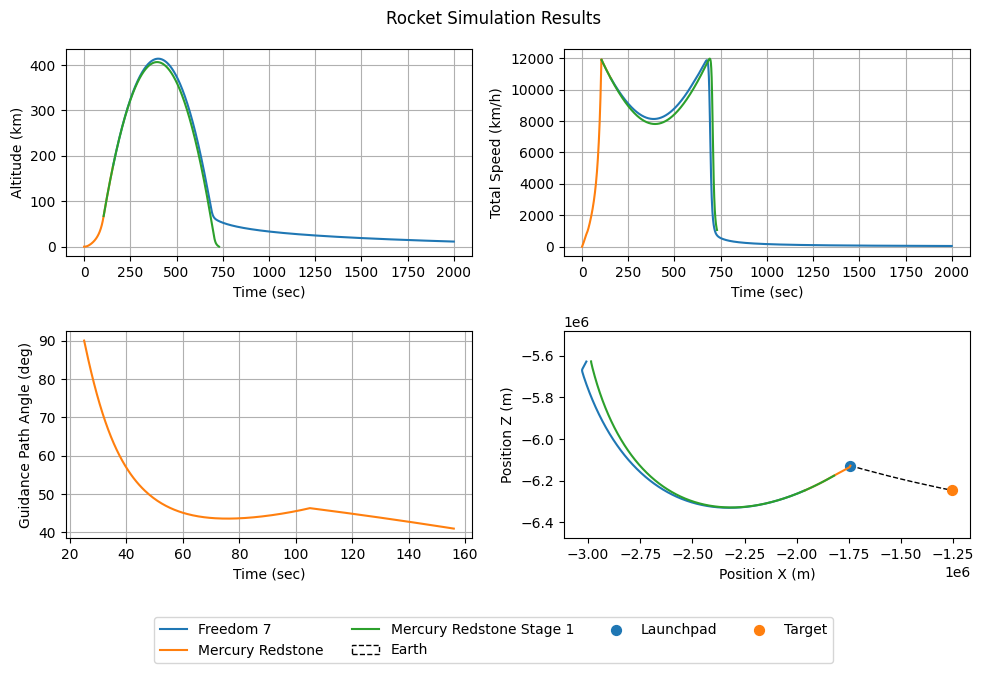

In [21]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed_kmh", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (km/h)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Rocket Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)

In [22]:
# Distance between launchpad and final position of the capsule in km
earth.surface_distance(launchpad, sim.final_objs[-1]) / 1000

np.float64(1361.6284025659434)